In [1]:
# CELL 1 — Setup & Upload Generated CSVs from Part B
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#1e1e2e'
plt.rcParams['figure.facecolor'] = '#1e1e2e'
plt.rcParams['axes.edgecolor'] = '#555'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

print('Upload the 3 generated CSV files from Part B:')
print('  1. fact_orders_enriched.csv')
print('  2. fact_user_risk_weekly.csv')
print('  3. investigation_queue.csv')
upload = files.upload()

Upload the 3 generated CSV files from Part B:
  1. fact_orders_enriched.csv
  2. fact_user_risk_weekly.csv
  3. investigation_queue.csv


Saving fact_orders_enriched.csv to fact_orders_enriched.csv
Saving fact_user_risk_weekly.csv to fact_user_risk_weekly.csv
Saving investigation_queue.csv to investigation_queue.csv


In [2]:
# CELL 2 — Load CSVs into DataFrames
import io

fact   = pd.read_csv(io.BytesIO(upload['fact_orders_enriched.csv']))
weekly = pd.read_csv(io.BytesIO(upload['fact_user_risk_weekly.csv']))
queue  = pd.read_csv(io.BytesIO(upload['investigation_queue.csv']))

fact['order_ts']     = pd.to_datetime(fact['order_ts'], errors='coerce')
weekly['week_start'] = pd.to_datetime(weekly['week_start'], errors='coerce')

print(f'fact_orders_enriched : {fact.shape}')
print(f'fact_user_risk_weekly: {weekly.shape}')
print(f'investigation_queue  : {queue.shape}')
print('\nColumns in fact:', list(fact.columns))

fact_orders_enriched : (4626, 28)
fact_user_risk_weekly: (3816, 12)
investigation_queue  : (98, 15)

Columns in fact: ['order_id', 'user_id', 'session_id', 'order_ts', 'gross_amount', 'discount_amount', 'net_amount', 'payment_method', 'coupon_id', 'coupon_discount_pct', 'item_count', 'total_qty', 'shipping_pincode', 'shipping_city_tier', 'payment_fail_count_before_success', 'device_reuse_count', 'pincode_reuse_count', 'order_value_zscore_by_category', 'qty_outlier_flag', 'multi_coupon_user_flag', 'high_discount_flag', 'new_user_flag', 'cod_flag', 'refund_amount', 'refund_approved', 'rto_flag', 'risk_score', 'risk_band']


=== SECTION 1: FRAUD LANDSCAPE DIAGNOSIS (WEEKLY) ===
      week  orders  refund_amount  rto_count  cod_count  payment_fail_counts  risk_score  high_discount_count
2025-07-28      23        1332.85          1          6                    6   14.434783                    0
2025-08-04     148       22991.76         14         43                   57   15.013514                    0
2025-08-11     182       49640.57         11         49                   55   13.736264                    0
2025-08-18     166      135630.82         10         35                   65   13.433735                    0
2025-08-25     161       95123.58         15         39                   68   14.248447                    0
2025-09-01     209       58701.09         21         70                   41   14.583732                    0
2025-09-08     179       51588.67         18         47                   55   14.346369                    0
2025-09-15     162       77919.56         13         43           

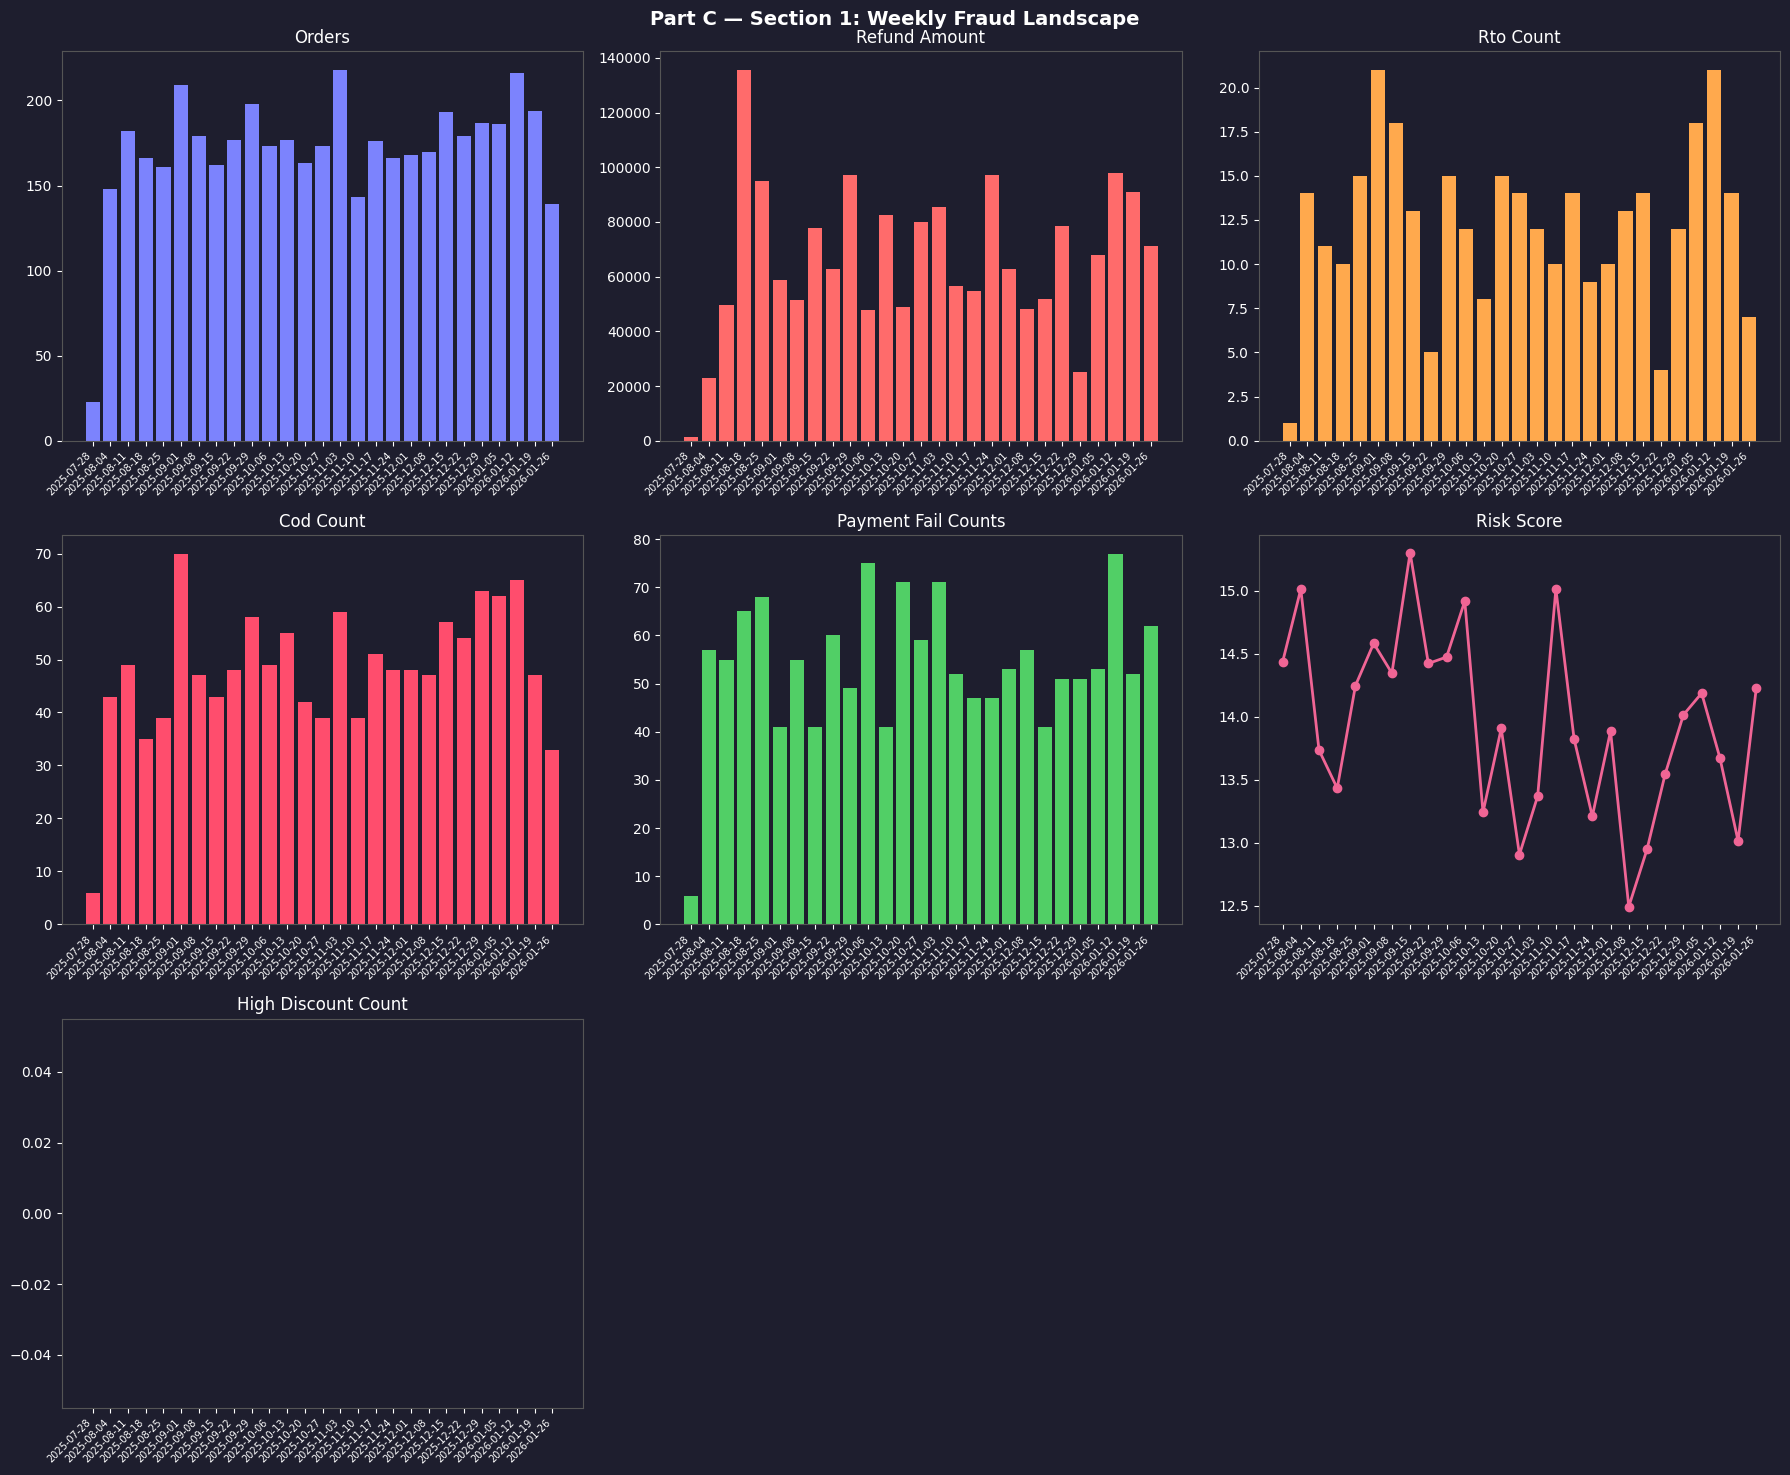


Top spike weeks:
      week  orders  refund_amount  rto_count  cod_count  payment_fail_counts  risk_score  high_discount_count
2025-11-03     218       85450.63         12         59                   71   13.371560                    0
2026-01-12     216       97954.54         21         65                   77   13.675926                    0
2025-09-01     209       58701.09         21         70                   41   14.583732                    0
Section 1 DONE.


In [3]:
# CELL 3 — SECTION 1: Fraud Landscape Diagnosis (Weekly Trends)
print('=== SECTION 1: FRAUD LANDSCAPE DIAGNOSIS (WEEKLY) ===')

f = fact.copy()
f['week'] = f['order_ts'].dt.to_period('W').apply(lambda r: r.start_time)

agg_dict = {'orders': ('order_id','count')}
for col, agg in [('refund_amount','sum'),('rto_flag','sum'),('cod_flag','sum'),
                  ('payment_fail_count_before_success','sum'),('risk_score','mean'),
                  ('high_discount_flag','sum')]:
    if col in f.columns:
        agg_dict[col.replace('_flag','_count').replace('_before_success','s')] = (col, agg)

wk = f.groupby('week').agg(**agg_dict).reset_index()
print(wk.to_string(index=False))

cols_to_plot = [c for c in wk.columns if c != 'week']
n = len(cols_to_plot)
nrows = (n + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(18, 5*nrows))
fig.suptitle('Part C — Section 1: Weekly Fraud Landscape', fontsize=14, color='white', fontweight='bold')
axes = axes.flatten() if nrows > 1 else axes
colors = ['#7c83fd','#ff6b6b','#ffa94d','#ff4d6d','#51cf66','#f06595','#74c0fc']

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    if 'score' in col or 'pct' in col:
        ax.plot(range(len(wk)), wk[col], color=colors[i%len(colors)], marker='o', linewidth=2)
    else:
        ax.bar(range(len(wk)), wk[col], color=colors[i%len(colors)])
    ax.set_xticks(range(len(wk)))
    ax.set_xticklabels([str(w.date()) for w in wk['week']], rotation=45, ha='right', fontsize=7)
    ax.set_title(col.replace('_',' ').title())

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('section1_weekly_trends.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nTop spike weeks:')
print(wk.sort_values('orders', ascending=False).head(3).to_string(index=False))
print('Section 1 DONE.')

=== SECTION 2: TOP FRAUD/ANOMALY PATTERNS ===

PATTERN 1 — Coupon Abuse (high_discount_flag=1):
  Orders=0, Loss proxy=₹0, New users=0

PATTERN 2 — Multiple Payment Failures (≥2 fails before success):
  Orders=281, Loss proxy=₹1,503,589
  Segment: channel x device

PATTERN 3 — COD Orders with RTO:
  Orders=153, Loss proxy=₹926,033
  Top pincodes: {569190.0: 10, 568518.0: 8, 563967.0: 5, 573709.0: 5, 575139.0: 4}

PATTERN 4 — Device Reuse (≥3 users per device):
  Orders=88, Loss proxy=₹532,361

PATTERN 5 — New User + COD + Multi-Coupon Abuse:
  Orders=4, Loss proxy=₹9,807


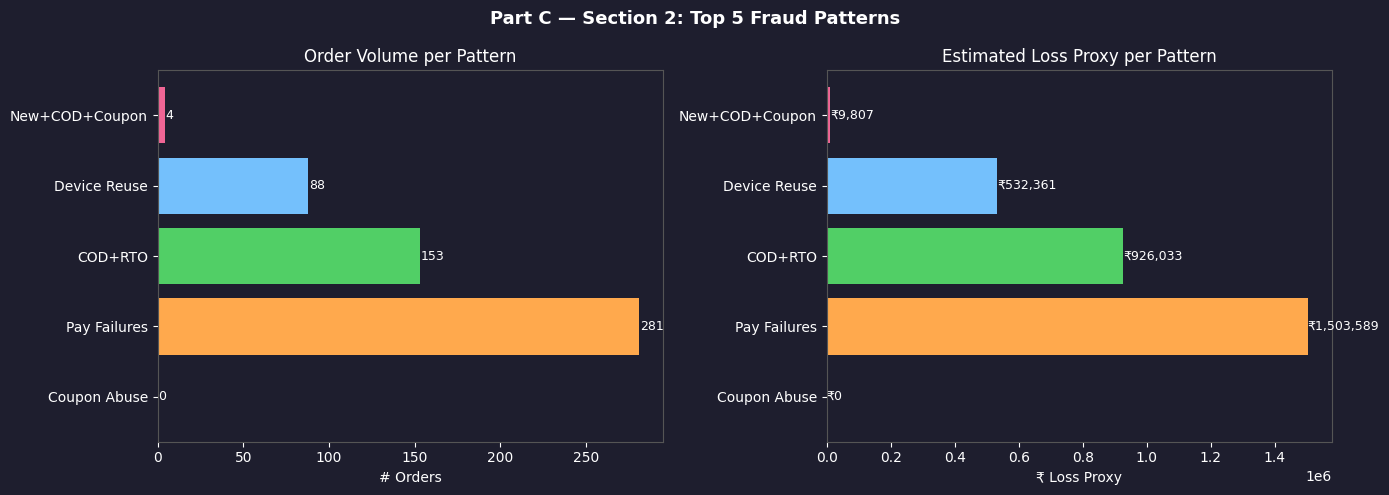


Section 2 DONE.


In [4]:
# CELL 4 — SECTION 2: Top 5 Fraud / Anomaly Patterns
print('=== SECTION 2: TOP FRAUD/ANOMALY PATTERNS ===')

f = fact.copy()

# Helper: estimate loss proxy = net_amount where applicable
loss_col = 'net_amount' if 'net_amount' in f.columns else 'gross_amount' if 'gross_amount' in f.columns else None

# PATTERN 1: Coupon Abuse — High discount orders concentrated in new users
p1 = f[f.get('high_discount_flag', pd.Series(0, index=f.index)) == 1] if 'high_discount_flag' in f.columns else pd.DataFrame()
p1_orders = len(p1)
p1_loss   = p1[loss_col].sum() if loss_col and len(p1) else 0
p1_new    = p1['new_user_flag'].sum() if 'new_user_flag' in p1.columns and len(p1) else 0
print(f'\nPATTERN 1 — Coupon Abuse (high_discount_flag=1):')
print(f'  Orders={p1_orders}, Loss proxy=₹{p1_loss:,.0f}, New users={p1_new}')

# PATTERN 2: Multiple payment failures then small success
p2 = f[f.get('payment_fail_count_before_success', pd.Series(0, index=f.index)) >= 2] if 'payment_fail_count_before_success' in f.columns else pd.DataFrame()
p2_orders = len(p2)
p2_loss   = p2[loss_col].sum() if loss_col and len(p2) else 0
print(f'\nPATTERN 2 — Multiple Payment Failures (≥2 fails before success):')
print(f'  Orders={p2_orders}, Loss proxy=₹{p2_loss:,.0f}')
if len(p2) and loss_col:
    print('  Segment: channel x device')
    if 'channel' in p2.columns and 'device' in p2.columns:
        print(p2.groupby(['channel','device'])[loss_col].agg(['count','sum']).sort_values('sum', ascending=False).head(5).to_string())

# PATTERN 3: COD orders from high-RTO pincodes
p3 = f[(f.get('cod_flag', pd.Series(0, index=f.index)) == 1) &
        (f.get('rto_flag', pd.Series(0, index=f.index)) == 1)] if ('cod_flag' in f.columns and 'rto_flag' in f.columns) else pd.DataFrame()
p3_orders = len(p3)
p3_loss   = p3[loss_col].sum() if loss_col and len(p3) else 0
print(f'\nPATTERN 3 — COD Orders with RTO:')
print(f'  Orders={p3_orders}, Loss proxy=₹{p3_loss:,.0f}')
if len(p3) and 'shipping_pincode' in p3.columns:
    print('  Top pincodes:', p3['shipping_pincode'].value_counts().head(5).to_dict())

# PATTERN 4: Device/IP reuse across many users
p4 = f[f.get('device_reuse_count', pd.Series(0, index=f.index)) >= 3] if 'device_reuse_count' in f.columns else pd.DataFrame()
p4_orders = len(p4)
p4_loss   = p4[loss_col].sum() if loss_col and len(p4) else 0
print(f'\nPATTERN 4 — Device Reuse (≥3 users per device):')
print(f'  Orders={p4_orders}, Loss proxy=₹{p4_loss:,.0f}')

# PATTERN 5: New user COD with multi-coupon abuse
p5 = f[(f.get('new_user_flag', pd.Series(0, index=f.index)) == 1) &
        (f.get('cod_flag', pd.Series(0, index=f.index)) == 1) &
        (f.get('multi_coupon_user_flag', pd.Series(0, index=f.index)) == 1)] if all(c in f.columns for c in ['new_user_flag','cod_flag','multi_coupon_user_flag']) else pd.DataFrame()
p5_orders = len(p5)
p5_loss   = p5[loss_col].sum() if loss_col and len(p5) else 0
print(f'\nPATTERN 5 — New User + COD + Multi-Coupon Abuse:')
print(f'  Orders={p5_orders}, Loss proxy=₹{p5_loss:,.0f}')

# Summary bar chart
patterns   = ['Coupon Abuse','Pay Failures','COD+RTO','Device Reuse','New+COD+Coupon']
order_cnts = [p1_orders, p2_orders, p3_orders, p4_orders, p5_orders]
loss_vals  = [p1_loss,   p2_loss,   p3_loss,   p4_loss,   p5_loss]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part C — Section 2: Top 5 Fraud Patterns', fontsize=13, color='white', fontweight='bold')
colors = ['#ff6b6b','#ffa94d','#51cf66','#74c0fc','#f06595']

ax1.barh(patterns, order_cnts, color=colors)
ax1.set_xlabel('# Orders')
ax1.set_title('Order Volume per Pattern')
for i, v in enumerate(order_cnts):
    ax1.text(v + 0.5, i, str(v), va='center', color='white', fontsize=9)

ax2.barh(patterns, loss_vals, color=colors)
ax2.set_xlabel('₹ Loss Proxy')
ax2.set_title('Estimated Loss Proxy per Pattern')
for i, v in enumerate(loss_vals):
    ax2.text(v + 0.5, i, f'₹{v:,.0f}', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('section2_fraud_patterns.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nSection 2 DONE.')

=== SECTION 3: SEGMENT DEEP DIVE ===

--- 3a: Channel x Device ---
  channel x device: columns ['channel', 'device'] not found, skipping

--- 3b: New vs Returning Users ---
user_type  orders     revenue    refunds  rto  avg_risk  refund_rate
      New     229  1260340.62   49957.49   15 23.087336         3.96
Returning    4397 27724767.91 1750984.85  315 13.421879         6.32

--- 3c: City Tier ---
shipping_city_tier  orders     revenue    refunds  rto  avg_risk  refund_rate
           unknown    4626 28985108.53 1800942.34  330 13.900346         6.21

--- 3d: Payment Method (COD vs Prepaid) ---
payment_method  orders    revenue   refunds  rto  avg_risk  refund_rate
           cod    1296 8135298.14      0.00  153 19.477623         0.00
        wallet     198 1132302.55 113922.66   14 12.257576        10.06
          card    1571 9827084.49 829176.34   85 12.116486         8.44
    netbanking     438 2668875.52 205128.56   26 11.404110         7.69
           upi    1123 7221547.83 65

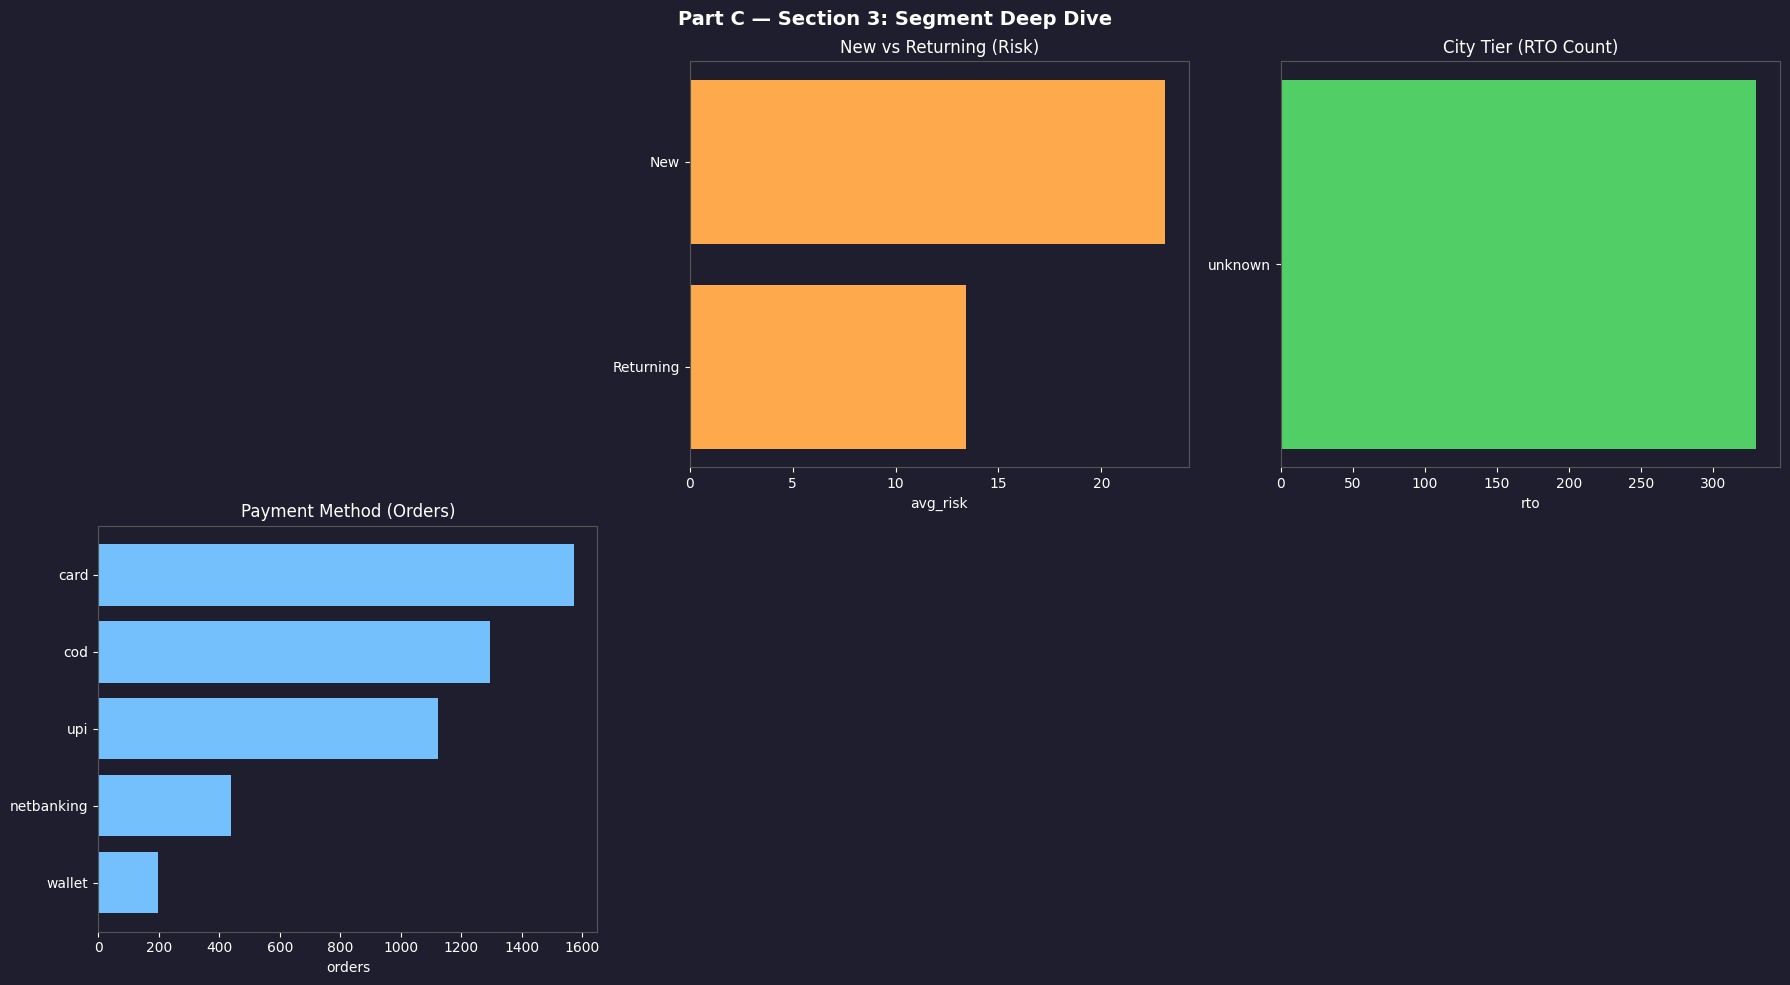


Top 3 segments by REFUND LOSS (channel x device):

Top 3 segments by RISK SCORE (channel x device):

Recommended Controls:
  - High-risk channel x device combos: block or add CAPTCHA verification
  - New users + COD: enforce OTP/address verification
  - Tier-3 pincodes with high RTO: flag for manual review before dispatch
  - High discount + new user: restrict coupon usage to verified accounts
Section 3 DONE.


In [5]:
# CELL 5 — SECTION 3: Segment Deep Dive
print('=== SECTION 3: SEGMENT DEEP DIVE ===')

f = fact.copy()
loss_col = 'net_amount' if 'net_amount' in f.columns else 'gross_amount' if 'gross_amount' in f.columns else 'order_id'

def seg_summary(df, grp_cols, label):
    available = [c for c in grp_cols if c in df.columns]
    if not available:
        print(f'  {label}: columns {grp_cols} not found, skipping')
        return pd.DataFrame()
    agg = {}
    agg['orders'] = ('order_id', 'count')
    if loss_col in df.columns: agg['revenue'] = (loss_col, 'sum')
    if 'refund_amount' in df.columns: agg['refunds'] = ('refund_amount', 'sum')
    if 'rto_flag' in df.columns: agg['rto'] = ('rto_flag', 'sum')
    if 'risk_score' in df.columns: agg['avg_risk'] = ('risk_score', 'mean')
    s = df.groupby(available).agg(**agg).reset_index()
    if 'refunds' in s.columns and 'revenue' in s.columns:
        s['refund_rate'] = (s['refunds'] / s['revenue'].replace(0,1) * 100).round(2)
    return s.sort_values('avg_risk' if 'avg_risk' in s.columns else 'orders', ascending=False)

# 3a: Channel x Device
print('\n--- 3a: Channel x Device ---')
s3a = seg_summary(f, ['channel','device'], 'channel x device')
if len(s3a): print(s3a.head(8).to_string(index=False))

# 3b: New vs Returning
print('\n--- 3b: New vs Returning Users ---')
if 'new_user_flag' in f.columns:
    f['user_type'] = f['new_user_flag'].map({1:'New',0:'Returning'})
    s3b = seg_summary(f, ['user_type'], 'new vs returning')
    print(s3b.to_string(index=False))

# 3c: City Tier
print('\n--- 3c: City Tier ---')
if 'shipping_city_tier' in f.columns:
    s3c = seg_summary(f, ['shipping_city_tier'], 'city tier')
    print(s3c.to_string(index=False))

# 3d: Payment Method
print('\n--- 3d: Payment Method (COD vs Prepaid) ---')
if 'payment_method' in f.columns:
    s3d = seg_summary(f, ['payment_method'], 'payment method')
    print(s3d.head(8).to_string(index=False))

# 3e: Top Categories
print('\n--- 3e: Top Categories ---')
if 'top_category' in f.columns:
    s3e = seg_summary(f, ['top_category'], 'top category')
    print(s3e.head(8).to_string(index=False))

# Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Part C — Section 3: Segment Deep Dive', fontsize=14, color='white', fontweight='bold')

def plot_seg(ax, df, grp, val, title, color='#7c83fd'):
    if df is None or len(df) == 0: ax.set_visible(False); return
    cols = [c for c in grp if c in df.columns]
    if not cols or val not in df.columns: ax.set_visible(False); return
    df2 = df.copy()
    df2['_label'] = df2[cols].astype(str).agg(' | '.join, axis=1)
    df2 = df2.sort_values(val, ascending=True).tail(8)
    ax.barh(df2['_label'], df2[val], color=color)
    ax.set_title(title)
    ax.set_xlabel(val)

plot_seg(axes[0,0], s3a, ['channel','device'], 'avg_risk', 'Channel x Device (Risk)', '#ff6b6b')
plot_seg(axes[0,1], s3b if 'new_user_flag' in f.columns else pd.DataFrame(), ['user_type'], 'avg_risk', 'New vs Returning (Risk)', '#ffa94d')
plot_seg(axes[0,2], s3c if 'shipping_city_tier' in f.columns else pd.DataFrame(), ['shipping_city_tier'], 'rto', 'City Tier (RTO Count)', '#51cf66')
plot_seg(axes[1,0], s3d if 'payment_method' in f.columns else pd.DataFrame(), ['payment_method'], 'orders', 'Payment Method (Orders)', '#74c0fc')
plot_seg(axes[1,1], s3e if 'top_category' in f.columns else pd.DataFrame(), ['top_category'], 'refund_rate' if 'refund_rate' in (s3e.columns if 'top_category' in f.columns else []) else 'orders', 'Top Category (Refund Rate %)', '#f06595')
plot_seg(axes[1,2], s3a, ['channel','device'], 'rto', 'Channel x Device (RTO)', '#cc5de8')

plt.tight_layout()
plt.savefig('section3_segment_deepdive.png', dpi=120, bbox_inches='tight')
plt.show()

# Top 3 segments by refund loss & risk
print('\nTop 3 segments by REFUND LOSS (channel x device):')
if 'refunds' in s3a.columns:
    print(s3a.nlargest(3,'refunds')[['channel','device','orders','refunds','avg_risk']].to_string(index=False))
print('\nTop 3 segments by RISK SCORE (channel x device):')
if 'avg_risk' in s3a.columns:
    print(s3a.nlargest(3,'avg_risk')[['channel','device','orders','avg_risk']].to_string(index=False))

print('\nRecommended Controls:')
print('  - High-risk channel x device combos: block or add CAPTCHA verification')
print('  - New users + COD: enforce OTP/address verification')
print('  - Tier-3 pincodes with high RTO: flag for manual review before dispatch')
print('  - High discount + new user: restrict coupon usage to verified accounts')
print('Section 3 DONE.')

In [6]:
# CELL 6 — SECTION 4: Investigation Table (Top 2 Fraud Patterns)
print('=== SECTION 4: INVESTIGATION TABLE (TOP 2 PATTERNS) ===')

from google.colab import files as colab_files

f = fact.copy()
loss_col = 'net_amount' if 'net_amount' in f.columns else 'gross_amount' if 'gross_amount' in f.columns else None

# ---- PATTERN A: Coupon Abuse ----
if 'high_discount_flag' in f.columns:
    pA = f[f['high_discount_flag'] == 1].copy()
else:
    pA = pd.DataFrame(columns=f.columns)

pA_rows = []
for _, row in pA.iterrows():
    hypo1 = 'Users create new accounts to exploit one-time coupon limits repeatedly'
    hypo2 = 'Stolen/borrowed coupons from reseller networks applied on high-value orders'
    evid   = f"discount_pct={row.get('coupon_discount_pct',0):.1f}%, order={row.get('order_id','?')}, new_user={row.get('new_user_flag',0)}, pincode={row.get('shipping_pincode','?')}"
    pA_rows.append({
        'pattern': 'Coupon Abuse',
        'pattern_definition': 'Order with coupon_discount_pct > 40% (high_discount_flag=1)',
        'order_id': row.get('order_id',''),
        'user_id':  row.get('user_id',''),
        'loss_proxy': row.get(loss_col, 0) if loss_col else 0,
        'concentrates_in': f"new_user={row.get('new_user_flag',0)} | pincode={row.get('shipping_pincode','?')} | channel={row.get('channel','?')}",
        'hypothesis_1': hypo1,
        'hypothesis_2': hypo2,
        'evidence': evid,
        'followup_experiment': 'A/B test: limit coupon use to users with >30 days account age; measure refund & abuse rate',
    })

# ---- PATTERN B: COD + RTO ----
if 'cod_flag' in f.columns and 'rto_flag' in f.columns:
    pB = f[(f['cod_flag']==1) & (f['rto_flag']==1)].copy()
else:
    pB = pd.DataFrame(columns=f.columns)

pB_rows = []
for _, row in pB.iterrows():
    hypo1 = 'Buyers in Tier-3 pincodes order COD without intent to pay, causing RTO losses'
    hypo2 = 'Fraudulent addresses used specifically to receive goods and reject delivery'
    evid   = f"cod=1, rto=1, pincode={row.get('shipping_pincode','?')}, device_reuse={row.get('device_reuse_count',0)}, risk={row.get('risk_score',0)}"
    pB_rows.append({
        'pattern': 'COD + RTO',
        'pattern_definition': 'COD order that resulted in Return-to-Origin (rto_flag=1)',
        'order_id': row.get('order_id',''),
        'user_id':  row.get('user_id',''),
        'loss_proxy': row.get(loss_col, 0) if loss_col else 0,
        'concentrates_in': f"pincode={row.get('shipping_pincode','?')} | city_tier={row.get('shipping_city_tier','?')} | device_reuse={row.get('device_reuse_count',0)}",
        'hypothesis_1': hypo1,
        'hypothesis_2': hypo2,
        'evidence': evid,
        'followup_experiment': 'Pilot: block COD for pincodes with >20% RTO history; compare RTO rate and revenue loss',
    })

table = pd.DataFrame(pA_rows + pB_rows)
print(f'Investigation table shape: {table.shape}')

# Summary by pattern
print('\nSummary:')
for pat in ['Coupon Abuse','COD + RTO']:
    sub = table[table['pattern']==pat]
    print(f'  {pat}: {len(sub)} orders, total loss proxy = ₹{sub["loss_proxy"].sum():,.0f}')

# Save
OUT = '/content/'
table.to_csv(f'{OUT}investigation_table_partC.csv', index=False)
print(f'\nSaved investigation_table_partC.csv with {len(table)} rows')

# Display top 10
display(table[['pattern','order_id','user_id','loss_proxy','concentrates_in','hypothesis_1','followup_experiment']].head(10))

# Download
colab_files.download(f'{OUT}investigation_table_partC.csv')
print('\n=== PART C COMPLETE ===')
print('All 4 sections done. 3 charts saved + investigation_table_partC.csv downloaded.')

=== SECTION 4: INVESTIGATION TABLE (TOP 2 PATTERNS) ===
Investigation table shape: (153, 10)

Summary:
  Coupon Abuse: 0 orders, total loss proxy = ₹0
  COD + RTO: 153 orders, total loss proxy = ₹926,033

Saved investigation_table_partC.csv with 153 rows


,pattern,order_id,user_id,loss_proxy,concentrates_in,hypothesis_1,followup_experiment
0,COD + RTO,o000000026,u000830,731.94,pincode=575139.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
1,COD + RTO,o000000050,u000152,14980.38,pincode=579266.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
2,COD + RTO,o000000077,u001895,10392.97,pincode=573709.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
3,COD + RTO,o000000090,u000125,1465.58,pincode=565285.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
4,COD + RTO,o000000104,u003087,9205.43,pincode=579266.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
5,COD + RTO,o000000195,u000277,2356.89,pincode=579884.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
6,COD + RTO,o000000207,u001171,7546.54,pincode=576088.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
7,COD + RTO,o000000231,NaN,13781.11,pincode=568408.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
8,COD + RTO,o000000297,u002062,12110.64,pincode=577545.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...
9,COD + RTO,o000000303,u001445,2175.02,pincode=569539.0 | city_tier=unknown | device_...,Buyers in Tier-3 pincodes order COD without in...,Pilot: block COD for pincodes with >20% RTO hi...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== PART C COMPLETE ===
All 4 sections done. 3 charts saved + investigation_table_partC.csv downloaded.
